In [6]:
print("Ambiente de teste")

Ambiente de teste


In [7]:
#Aula 1 - Pandas

In [8]:
import pandas as pd
url = "https://raw.githubusercontent.com/alura-cursos/immersao-dados-2-2020/master/MICRODADOS_ENEM_2019_SAMPLE_43278.csv"
print("Pandas importado e pronto para ler dados.")
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

Pandas importado e pronto para ler dados.


In [9]:
df.head(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  str    
 2   employment_type     133349 non-null  str    
 3   job_title           133349 non-null  str    
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  str    
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  str    
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  str    
 10  company_size        133349 non-null  str    
dtypes: float64(1), int64(3), str(7)
memory usage: 11.2 MB


In [11]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [12]:
df.shape

(133349, 11)

In [13]:
linhas, colunas = df.shape[0], df.shape[1]
print("linhas:", linhas)
print("colunas:", colunas)

linhas: 133349
colunas: 11


In [14]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [15]:
renomear = {
    'work_year': 'ano',
    'experience_level': 'nivel_experiencia',
    'employment_type': 'tipo_emprego',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda_salario',
    'salary_in_usd': 'salario_usd',
    'employee_residence': 'residencia_empregado',
    'remote_ratio': 'remoto',
    'company_location': 'localizacao_empresa',
    'company_size': 'tamanho_empresa'
}

df.rename(columns=renomear, inplace=True)
df.columns

Index(['ano', 'nivel_experiencia', 'tipo_emprego', 'cargo', 'salario',
       'moeda_salario', 'salario_usd', 'residencia_empregado', 'remoto',
       'localizacao_empresa', 'tamanho_empresa'],
      dtype='str')

In [16]:
df["nivel_experiencia"].value_counts()

nivel_experiencia
SE    77241
MI    40465
EN    12443
EX     3200
Name: count, dtype: int64

In [17]:
df["tipo_emprego"].value_counts()

tipo_emprego
FT    132563
CT       394
PT       376
FL        16
Name: count, dtype: int64

In [18]:
df["remoto"].value_counts()

remoto
0      105312
100     27718
50        319
Name: count, dtype: int64

In [19]:
# traduzir categorias da coluna 'cargo' para português (cria coluna nova 'cargo_pt')
def traduzir_cargo(t):
    if pd.isna(t):
        return t
    s = t.lower()
    if 'principal data scientist' in s:
        return 'Cientista de Dados Principal'
    if 'lead data scientist' in s or 'staff data scientist' in s:
        return 'Cientista de Dados Sênior'
    if 'data scientist' in s:
        return 'Cientista de Dados'
    if 'data engineer' in s:
        return 'Engenheiro de Dados'
    if 'machine learning engineer' in s or 'ml engineer' in s:
        return 'Engenheiro de Machine Learning'
    if 'machine learning scientist' in s:
        return 'Cientista de Machine Learning'
    if 'data analyst' in s:
        if 'business' in s:
            return 'Analista de Dados de Negócios'
        if 'product' in s:
            return 'Analista de Dados de Produto'
        return 'Analista de Dados'
    if 'analytics engineer' in s:
        return 'Engenheiro de Analytics'
    if 'data architect' in s:
        return 'Arquiteto de Dados'
    if 'research scientist' in s:
        return 'Cientista de Pesquisa'
    if 'applied scientist' in s:
        return 'Cientista Aplicado'
    if 'data science' in s and 'manager' in s:
        return 'Gerente de Ciência de Dados'
    if 'manager' in s and 'data' in s:
        return 'Gerente de Dados'
    if 'director' in s and 'data' in s:
        return 'Diretor de Dados'
    # fallback: retorna título original se não houver mapeamento específico
    return t

df['cargo_pt'] = df['cargo'].apply(traduzir_cargo)

# mostrar as top traduções (opcional)
df['cargo_pt'].value_counts().head(30)

cargo_pt
Cientista de Dados                17347
Software Engineer                 15007
Engenheiro de Dados               14908
Analista de Dados                 12435
Engineer                           9456
Engenheiro de Machine Learning     8220
Manager                            6679
Analyst                            4364
Cientista de Pesquisa              3212
Product Manager                    2230
Cientista Aplicado                 2205
Associate                          2073
Arquiteto de Dados                 2029
Engenheiro de Analytics            1901
Gerente de Dados                   1643
AI Engineer                        1620
Research Engineer                  1614
Consultant                         1125
Business Intelligence Engineer      870
Data Specialist                     854
Developer                           832
Solutions Architect                 802
Engineering Manager                 776
Systems Engineer                    724
Software Developer             

In [20]:
# traduzir categorias da coluna 'remoto' para português
mapa_remoto = {
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
}

df['remoto_pt'] = df['remoto'].map(mapa_remoto)

# mostrar a tradução
df['remoto_pt'].value_counts()

remoto_pt
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64

In [21]:
df.head()

,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M,Solutions Engineer,Remoto
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M,Solutions Engineer,Remoto
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M,Engenheiro de Dados,Presencial
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M,Engenheiro de Dados,Presencial
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M,Engenheiro de Dados,Presencial


In [22]:
df.describe(include="object")

/tmp/ipykernel_7730/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,nivel_experiencia,tipo_emprego,cargo,moeda_salario,residencia_empregado,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
count,133349,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,95,3,330,3
top,SE,FT,Data Scientist,USD,US,US,M,Cientista de Dados,Presencial
freq,77241,132563,17314,126140,119579,119641,129561,17347,105312


In [23]:
print("Senha da Aula 1")
print("Pandas")

Senha da Aula 1
Pandas


In [24]:
# Aula 2 - Limpando os dados

In [25]:
df.isnull()


,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False,False,False


In [26]:
df.isnull().sum()

ano                     10
nivel_experiencia        0
tipo_emprego             0
cargo                    0
salario                  0
moeda_salario            0
salario_usd              0
residencia_empregado     0
remoto                   0
localizacao_empresa      0
tamanho_empresa          0
cargo_pt                 0
remoto_pt                0
dtype: int64

In [27]:
df['ano'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [28]:
df[df.isnull().any(axis=1)]

,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
5588,NaN,SE,FT,Product Manager,184500,USD,184500,US,0,US,M,Product Manager,Presencial
59692,NaN,MI,FT,Engineer,110000,USD,110000,DE,0,DE,M,Engineer,Presencial
59710,NaN,EN,FT,Data Scientist,208800,USD,208800,US,0,US,M,Cientista de Dados,Presencial
59759,NaN,SE,FT,Software Engineer,135000,USD,135000,US,0,US,M,Software Engineer,Presencial
59789,NaN,SE,FT,Engineer,112000,USD,112000,US,0,US,M,Engineer,Presencial
131000,NaN,SE,FT,Machine Learning Engineer,163800,USD,163800,US,0,US,M,Engenheiro de Machine Learning,Presencial
131006,NaN,SE,FT,Data Analytics Manager,204500,USD,204500,US,0,US,M,Gerente de Dados,Presencial
133054,NaN,EN,FT,Data Scientist,40000,USD,40000,JP,100,MY,L,Cientista de Dados,Remoto
133281,NaN,MI,FT,Machine Learning Engineer,180000,PLN,46597,PL,100,PL,L,Engenheiro de Machine Learning,Remoto
133317,NaN,MI,FT,Data Scientist,130000,USD,130000,US,50,US,L,Cientista de Dados,Híbrido


In [29]:
import numpy as np

df_salarios= pd.DataFrame({
"nome" :["Pedro", "Ana", "Maria","Carlos","Wal"],
"salario" : [3500, np.nan, 5000, np.nan,100000]
})
'''Calcular a média e mediana dos salários, preenchendo os valores nulos com a média'''
df_salarios["salario_media"]= df_salarios["salario"].fillna(df_salarios["salario"].mean().round(2))
df_salarios["salario_mediana"] = df_salarios["salario"].median()
df_salarios

,nome,salario,salario_media,salario_mediana
0,Pedro,3500.0,3500.00,5000.0
1,Ana,NaN,36166.67,5000.0
2,Maria,5000.0,5000.00,5000.0
3,Carlos,NaN,36166.67,5000.0
4,Wal,100000.0,100000.00,5000.0


In [30]:
df_temperaturas = pd.DataFrame({
    "dias" : ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    "temperaturas" : [31, np.nan, np.nan, 28 ,27]
})

df_temperaturas["preenchido_ffill"] = df_temperaturas["temperaturas"].ffill()
df_temperaturas

,dias,temperaturas,preenchido_ffill
0,Segunda,31.0,31.0
1,Terça,NaN,31.0
2,Quarta,NaN,31.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [31]:
df_temperaturas = pd.DataFrame({
    "dias" : ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    "temperaturas" : [31, np.nan, np.nan, 28 ,27]
})

df_temperaturas["preenchido_bfill"] = df_temperaturas["temperaturas"].bfill()
df_temperaturas

,dias,temperaturas,preenchido_bfill
0,Segunda,31.0,31.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [32]:
df_cidades = pd.DataFrame({
    "nome" :["Pedro", "Ana", "Maria","Carlos","Wal"],
    "cidade" : ["São Paulo", "Rio de Janeiro", np.nan, "Natal", np.nan]
    
})
df_cidades["cidade_preenchida"] = df_cidades["cidade"].fillna("Não informado")
df_cidades

,nome,cidade,cidade_preenchida
0,Pedro,São Paulo,São Paulo
1,Ana,Rio de Janeiro,Rio de Janeiro
2,Maria,NaN,Não informado
3,Carlos,Natal,Natal
4,Wal,NaN,Não informado


In [33]:
df_limpo = df.dropna()
df_limpo.isnull().sum()

ano                     0
nivel_experiencia       0
tipo_emprego            0
cargo                   0
salario                 0
moeda_salario           0
salario_usd             0
residencia_empregado    0
remoto                  0
localizacao_empresa     0
tamanho_empresa         0
cargo_pt                0
remoto_pt               0
dtype: int64

In [34]:
df_limpo.head()

,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M,Solutions Engineer,Remoto
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M,Solutions Engineer,Remoto
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M,Engenheiro de Dados,Presencial
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M,Engenheiro de Dados,Presencial
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M,Engenheiro de Dados,Presencial


In [35]:
df_limpo.info()

<class 'pandas.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ano                   133339 non-null  float64
 1   nivel_experiencia     133339 non-null  str    
 2   tipo_emprego          133339 non-null  str    
 3   cargo                 133339 non-null  str    
 4   salario               133339 non-null  int64  
 5   moeda_salario         133339 non-null  str    
 6   salario_usd           133339 non-null  int64  
 7   residencia_empregado  133339 non-null  str    
 8   remoto                133339 non-null  int64  
 9   localizacao_empresa   133339 non-null  str    
 10  tamanho_empresa       133339 non-null  str    
 11  cargo_pt              133339 non-null  str    
 12  remoto_pt             133339 non-null  str    
dtypes: float64(1), int64(3), str(9)
memory usage: 14.2 MB


In [36]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int'))
df_limpo.info()
df_limpo.head()

<class 'pandas.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   ano                   133339 non-null  int64
 1   nivel_experiencia     133339 non-null  str  
 2   tipo_emprego          133339 non-null  str  
 3   cargo                 133339 non-null  str  
 4   salario               133339 non-null  int64
 5   moeda_salario         133339 non-null  str  
 6   salario_usd           133339 non-null  int64
 7   residencia_empregado  133339 non-null  str  
 8   remoto                133339 non-null  int64
 9   localizacao_empresa   133339 non-null  str  
 10  tamanho_empresa       133339 non-null  str  
 11  cargo_pt              133339 non-null  str  
 12  remoto_pt             133339 non-null  str  
dtypes: int64(4), str(9)
memory usage: 14.2 MB


,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
0,2025,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M,Solutions Engineer,Remoto
1,2025,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M,Solutions Engineer,Remoto
2,2025,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M,Engenheiro de Dados,Presencial
3,2025,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M,Engenheiro de Dados,Presencial
4,2025,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M,Engenheiro de Dados,Presencial


In [37]:
print("Senha da Aula 2")
print("Print")

Senha da Aula 2
Print


In [38]:
#Aula 3 - Gráficos

In [39]:
df_limpo.head()

,ano,nivel_experiencia,tipo_emprego,cargo,salario,moeda_salario,salario_usd,residencia_empregado,remoto,localizacao_empresa,tamanho_empresa,cargo_pt,remoto_pt
0,2025,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M,Solutions Engineer,Remoto
1,2025,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M,Solutions Engineer,Remoto
2,2025,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M,Engenheiro de Dados,Presencial
3,2025,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M,Engenheiro de Dados,Presencial
4,2025,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M,Engenheiro de Dados,Presencial


<Axes: title={'center': 'Distribuição dos Níveis de Experiência'}, xlabel='nivel_experiencia'>

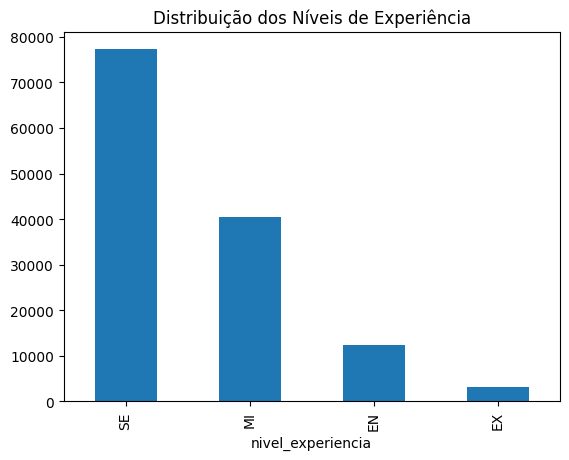

In [40]:
df_limpo["nivel_experiencia"].value_counts().plot(kind='bar', title='Distribuição dos Níveis de Experiência')

In [41]:
import seaborn as sns

<Axes: xlabel='nivel_experiencia', ylabel='salario_usd'>

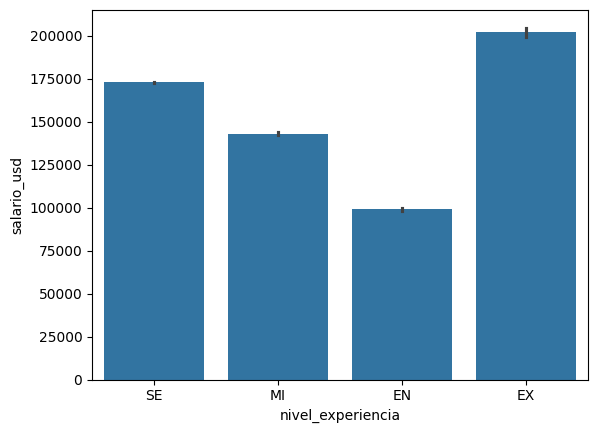

In [42]:
sns.barplot(x='nivel_experiencia', y='salario_usd', data=df_limpo)

In [43]:
import matplotlib.pyplot as plt

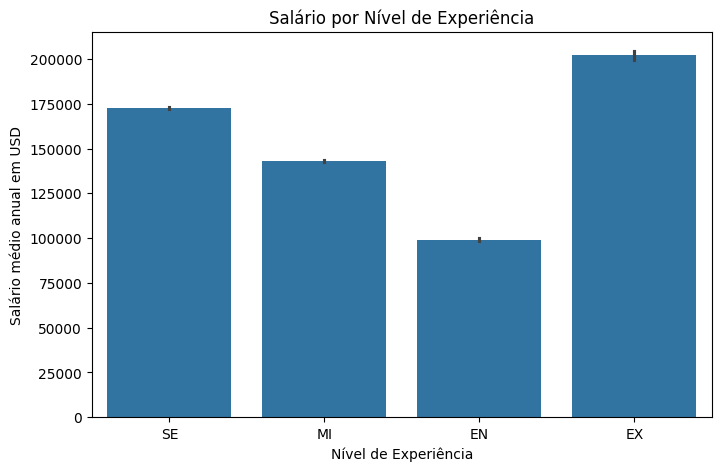

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x='nivel_experiencia', y='salario_usd', data=df_limpo)
plt.title('Salário por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário médio anual em USD')
plt.show()

In [45]:
df_limpo.groupby("nivel_experiencia")["salario_usd"].mean().sort_values(ascending=False)


nivel_experiencia
EX    202027.667813
SE    172850.838301
MI    143044.845979
EN     99034.963267
Name: salario_usd, dtype: float64

In [46]:
ordem = df_limpo.groupby("nivel_experiencia")["salario_usd"].mean().sort_values(ascending=False).index

In [47]:
ordem

Index(['EX', 'SE', 'MI', 'EN'], dtype='str', name='nivel_experiencia')

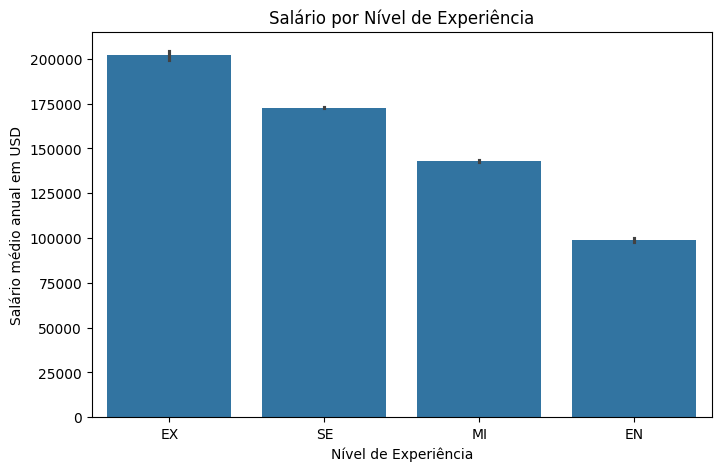

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x='nivel_experiencia', y='salario_usd', data=df_limpo, order=ordem)
plt.title('Salário por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário médio anual em USD')
plt.show()  

In [ ]:
mapa_nivel_experiencia = {
    'EN': 'Nível Iniciante',
    'MI': 'Nível Intermediário',
    'SE': 'Nível Sênior',
    'EX': 'Nível Executivo'
}

df_limpo['nivel_experiencia_pt'] = df_limpo['nivel_experiencia'].map(mapa_nivel_experiencia)
df_limpo['nivel_experiencia_pt'].value_counts()